## Step 1:Import libraries
# Pandas-data loading,cleaning,time handling
# numpy-numerical operations

In [104]:
import pandas as pd
import numpy as np

Provides metrics to measure prediction error.
Easy to interpret.
Less sensitive to extreme values.

In [105]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



In [ ]:
pip install matplotlib

In [108]:
import matplotlib.pyplot as plt

In [136]:
df=pd.read_csv('calls.csv')

In [137]:
df.head()

,StartDateTime,UserId,CallType,disconnectType,Total_Handle_Time,Total_Hold_Time,Total_Talk_Time,Unnamed: 7,Unnamed: 8
0,1/1/2023 5:01:42 AM,da7fadb4-cad9-4062-8271-bbc999ac1275,Inbound_Queue,endpoint,1188.162,0.000,1075.162,NaN,NaN
1,1/1/2023 5:11:53 AM,af512203-3ea2-48d5-bbf5-e46ae915d4d8,Inbound_Queue,peer,396.923,0.000,216.923,NaN,NaN
2,1/1/2023 5:24:17 AM,6b633a32-ec20-48f4-91dd-503d459eda1f,Inbound_Queue,peer,537.893,173.363,361.544,NaN,NaN
3,1/1/2023 6:01:03 AM,63bb6f93-004c-4a79-8d01-7de24f75241b,Inbound_Queue,peer,266.625,0.000,263.625,NaN,NaN
4,1/1/2023 6:04:02 AM,e47ca893-1edc-49e9-b0bd-58cde8182443,Inbound_Queue,peer,2545.198,856.591,1674.901,NaN,NaN


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135859 entries, 0 to 135858
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   StartDateTime      135859 non-null  object 
 1   UserId             135859 non-null  object 
 2   CallType           135859 non-null  object 
 3   disconnectType     135830 non-null  object 
 4   Total_Handle_Time  135859 non-null  float64
 5   Total_Hold_Time    135859 non-null  float64
 6   Total_Talk_Time    135859 non-null  float64
 7   Unnamed: 7         0 non-null       float64
 8   Unnamed: 8         0 non-null       float64
dtypes: float64(5), object(4)
memory usage: 9.3+ MB


In [139]:
df['StartDateTime']=pd.to_datetime(df['StartDateTime'])

In [140]:
df.head()

,StartDateTime,UserId,CallType,disconnectType,Total_Handle_Time,Total_Hold_Time,Total_Talk_Time,Unnamed: 7,Unnamed: 8
0,2023-01-01 05:01:42,da7fadb4-cad9-4062-8271-bbc999ac1275,Inbound_Queue,endpoint,1188.162,0.000,1075.162,NaN,NaN
1,2023-01-01 05:11:53,af512203-3ea2-48d5-bbf5-e46ae915d4d8,Inbound_Queue,peer,396.923,0.000,216.923,NaN,NaN
2,2023-01-01 05:24:17,6b633a32-ec20-48f4-91dd-503d459eda1f,Inbound_Queue,peer,537.893,173.363,361.544,NaN,NaN
3,2023-01-01 06:01:03,63bb6f93-004c-4a79-8d01-7de24f75241b,Inbound_Queue,peer,266.625,0.000,263.625,NaN,NaN
4,2023-01-01 06:04:02,e47ca893-1edc-49e9-b0bd-58cde8182443,Inbound_Queue,peer,2545.198,856.591,1674.901,NaN,NaN


In [141]:
df=df.sort_values('StartDateTime').reset_index(drop=True)

In [142]:
df.head(14)

,StartDateTime,UserId,CallType,disconnectType,Total_Handle_Time,Total_Hold_Time,Total_Talk_Time,Unnamed: 7,Unnamed: 8
0,2023-01-01 05:01:42,da7fadb4-cad9-4062-8271-bbc999ac1275,Inbound_Queue,endpoint,1188.162,0.000,1075.162,NaN,NaN
1,2023-01-01 05:11:53,af512203-3ea2-48d5-bbf5-e46ae915d4d8,Inbound_Queue,peer,396.923,0.000,216.923,NaN,NaN
2,2023-01-01 05:24:17,6b633a32-ec20-48f4-91dd-503d459eda1f,Inbound_Queue,peer,537.893,173.363,361.544,NaN,NaN
3,2023-01-01 06:01:03,63bb6f93-004c-4a79-8d01-7de24f75241b,Inbound_Queue,peer,266.625,0.000,263.625,NaN,NaN
4,2023-01-01 06:04:02,e47ca893-1edc-49e9-b0bd-58cde8182443,Inbound_Queue,peer,2545.198,856.591,1674.901,NaN,NaN
5,2023-01-01 06:04:40,7e5d301d-a5e1-499f-8423-5300e8392c5a,Inbound_Queue,client,1027.725,20.607,1005.118,NaN,NaN
6,2023-01-01 06:11:24,02709d36-9970-4d79-bc59-6c932dfd7c2e,Inbound_Queue,client,2296.168,0.000,2293.168,NaN,NaN
7,2023-01-01 06:16:08,53d692a1-d4da-4d9d-a256-33737d264b15,Inbound_Queue,peer,1597.976,843.893,574.083,NaN,NaN
8,2023-01-01 06:16:48,0ad1d053-a3a3-4056-a412-f4ac54609ed3,Inbound_Queue,peer,1155.306,320.501,654.805,NaN,NaN
9,2023-01-01 06:17:17,4ff996ef-9f41-4fc7-9894-333cd0364bcc,Inbound_Queue,peer,898.486,0.000,718.486,NaN,NaN


In [144]:
target='Total_Handle_Time'

-Time windows
->Raw data=one raw per call
--Ml time series works better with  time windows

In [145]:
df=df.set_index('StartDateTime')

ts=df.resample('10T').agg({
    'Total_Handle_Time':'mean',
    'Total_Hold_Time':'mean',
    'Total_Talk_Time':'mean'
})

C:\Users\MURIUKI\AppData\Local\Temp\ipykernel_9300\2147428230.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts=df.resample('10T').agg({


In [146]:
ts.isnull().sum()

Total_Handle_Time    4442
Total_Hold_Time      4442
Total_Talk_Time      4442
dtype: int64

In [147]:
ts

,Total_Handle_Time,Total_Hold_Time,Total_Talk_Time
StartDateTime,,,
2023-01-01 05:00:00,1188.162000,0.000000,1075.16200
2023-01-01 05:10:00,396.923000,0.000000,216.92300
2023-01-01 05:20:00,537.893000,173.363000,361.54400
2023-01-01 05:30:00,NaN,NaN,NaN
2023-01-01 05:40:00,NaN,NaN,NaN
...,...,...,...
2023-03-15 18:10:00,1558.753167,416.483333,1003.22800
2023-03-15 18:20:00,834.522000,23.573500,692.76725
2023-03-15 18:30:00,1491.483750,53.915250,1257.56850


In [148]:
ts=ts.dropna()

## Feature engineering-create awareness
- Lags-give the model memory

In [149]:
ts['lag_1'] = ts[target].shift(1)
ts['lag_2'] = ts[target].shift(2)
ts['lag_3'] = ts[target].shift(3)

C:\Users\MURIUKI\AppData\Local\Temp\ipykernel_9300\2737039669.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['lag_1'] = ts[target].shift(1)
C:\Users\MURIUKI\AppData\Local\Temp\ipykernel_9300\2737039669.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['lag_2'] = ts[target].shift(2)
C:\Users\MURIUKI\AppData\Local\Temp\ipykernel_9300\2737039669.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


In [150]:
ts['rolling_mean_3'] = ts[target].shift(1).rolling(3).mean()
ts['rolling_std_3']  = ts[target].shift(1).rolling(3).std()

ts


C:\Users\MURIUKI\AppData\Local\Temp\ipykernel_9300\3624712564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['rolling_mean_3'] = ts[target].shift(1).rolling(3).mean()
C:\Users\MURIUKI\AppData\Local\Temp\ipykernel_9300\3624712564.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['rolling_std_3']  = ts[target].shift(1).rolling(3).std()


,Total_Handle_Time,Total_Hold_Time,Total_Talk_Time,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
StartDateTime,,,,,,,,
2023-01-01 05:00:00,1188.162000,0.000000,1075.162000,NaN,NaN,NaN,NaN,NaN
2023-01-01 05:10:00,396.923000,0.000000,216.923000,1188.162000,NaN,NaN,NaN,NaN
2023-01-01 05:20:00,537.893000,173.363000,361.544000,396.923000,1188.162000,NaN,NaN,NaN
2023-01-01 06:00:00,1279.849333,292.399333,981.214667,537.893000,396.923000,1188.162000,707.659333,422.054789
2023-01-01 06:10:00,1486.984000,291.098500,1060.135500,1279.849333,537.893000,396.923000,738.221778,474.329466
...,...,...,...,...,...,...,...,...
2023-03-15 18:10:00,1558.753167,416.483333,1003.228000,1257.826500,1469.373857,1355.773333,1360.991230,105.870161
2023-03-15 18:20:00,834.522000,23.573500,692.767250,1558.753167,1257.826500,1469.373857,1428.651175,154.541151
2023-03-15 18:30:00,1491.483750,53.915250,1257.568500,834.522000,1558.753167,1257.826500,1217.033889,363.834748


In [151]:
ts.head()

,Total_Handle_Time,Total_Hold_Time,Total_Talk_Time,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
StartDateTime,,,,,,,,
2023-01-01 05:00:00,1188.162000,0.000000,1075.162000,NaN,NaN,NaN,NaN,NaN
2023-01-01 05:10:00,396.923000,0.000000,216.923000,1188.162000,NaN,NaN,NaN,NaN
2023-01-01 05:20:00,537.893000,173.363000,361.544000,396.923000,1188.162,NaN,NaN,NaN
2023-01-01 06:00:00,1279.849333,292.399333,981.214667,537.893000,396.923,1188.162,707.659333,422.054789
2023-01-01 06:10:00,1486.984000,291.098500,1060.135500,1279.849333,537.893,396.923,738.221778,474.329466


In [153]:
ts = ts.dropna()

In [130]:
x = ts[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']]

y = ts[target]

split_index = int(len(ts)*0.7)

x_train, x_test = x[:split_index], x[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [165]:
lr = LinearRegression()
lr.fit(x_train, y_train)

pred_lr = lr.predict(x_test)
print('Linear Reg MEA:', mean_absolute_error(y_test, pred_lr))

Linear Reg MEA: 243.21552615955105


In [163]:
X=ts[['lag_1','lag_2','lag_3','rolling_mean_3','rolling_std_3']]
y=ts[target]

split_index=int(len(ts)*0.7)

x_train,x_test=x[:split_index],x[split_index:]
y_train,y_test=y[:split_index],y[split_index:]



In [170]:
lr=LinearRegression()
lr.fit(x_train,y_train)

pred_lr=lr.predict(x_test)

In [169]:
mean_absolute_error(y_test,pred_lr)

243.21552615955105

In [171]:
rf=RandomForestRegressor(
    n_estimators=300,
    random_state=42   
)

rf.fit(x_train,y_train)
pred_rf=rf.predict(x_test)

In [172]:
pred_rf

array([1310.31729737, 1521.50104532, 1298.84595689, ..., 1170.05816642,
       1293.22106351, 1324.95129697], shape=(1846,))

In [173]:
mean_absolute_error(y_test,pred_rf)

256.179675737572

In [178]:
svr= Pipeline([
('scaler',StandardScaler()),
('svr',SVR(kernel='rbf',C=100,gamma=0.1))
])

svr.fit(x_train,y_train)
pred_svr=svr.predict(x_test)


In [179]:
pred_svr

array([1287.60908777, 1187.27469948, 1327.29405756, ..., 1246.50309208,
       1277.96698609, 1241.42011565], shape=(1846,))

In [180]:
mean_absolute_error(y_test,pred_svr)

241.91358220648766

Text(0, 0.5, 'Seconds')

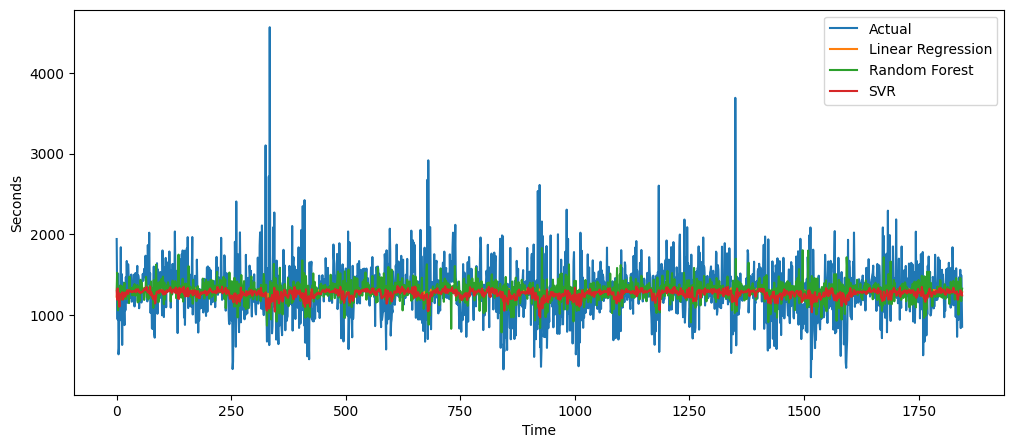

In [182]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values,label='Actual')
plt.plot(pred_lr,label='Linear Regression')
plt.plot(pred_rf,label='Random Forest')
plt.plot(pred_svr,label='SVR')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Seconds')
